## **Visión por Computadora I : TP3**
**Integrantes:**

Carmen Rodríguez

Matías Bovio

Gonzalo Rodríguez

# TP3 - Detección de logos con template matching

Visión por Computadora I - CEIA

Se busca el logo de Coca-Cola en las imágenes de la carpeta `images` a partir del template `template/pattern.png`.

Resumen del método:
- Template matching (`TM_CCOEFF_NORMED`) sobre **bordes de Canny** del template y de la imagen, para no depender del color ni de los fondos uniformes.
- Búsqueda en **varias escalas** del template con `cv.resize`.
- Para múltiples detecciones: umbral sobre el mapa de coincidencia + **supresión de no máximos con IoU**.
- Ningún parámetro está fijado para una imagen en particular: los umbrales de Canny, el rango de escalas y el umbral de detección se calculan a partir de cada imagen.

El análisis exploratorio con el que se eligieron los rangos y umbrales está en la notebook aparte `TP3_EXPLORACION.ipynb`.

In [15]:
%matplotlib inline
import os
import glob
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

In [16]:
# las carpetas images/ y template/ están al lado de la notebook
carpeta = '.'

template_bgr = cv.imread(os.path.join(carpeta, 'template', 'pattern.png'))
rutas = sorted(glob.glob(os.path.join(carpeta, 'images', '*')))
imagenes = {os.path.basename(r): cv.imread(r) for r in rutas}

print('Template:', template_bgr.shape)
print('Imágenes:', list(imagenes))

Template: (175, 400, 3)
Imágenes: ['COCA-COLA-LOGO.jpg', 'coca_logo_1.png', 'coca_logo_2.png', 'coca_multi.png', 'coca_retro_1.png', 'coca_retro_2.png', 'logo_1.png']


### Preprocesamiento

- `bordes`: Canny con umbrales calculados a partir de la mediana de la imagen (0.66 y 1.33 veces la mediana) y un suavizado gaussiano sobre los bordes, para que toleren pequeñas diferencias de escala o de forma.
- El template se recorta al rectángulo que contiene al logo (el `pattern.png` tiene bastante margen blanco).
- Escalas: el ancho del template va desde 1/8 de su tamaño original hasta el ancho de la imagen, con pasos geométricos.

In [17]:
def bordes(gris):
    med = np.median(gris)
    bajo = int(max(0, 0.66 * med))
    alto = int(min(255, 1.33 * med))
    edges = cv.Canny(gris, bajo, alto)
    return cv.GaussianBlur(edges, (5, 5), 0)


template = cv.cvtColor(template_bgr, cv.COLOR_BGR2GRAY)
ys, xs = np.where(cv.Canny(template, 50, 150) > 0)
template = template[ys.min():ys.max() + 1, xs.min():xs.max() + 1]


def escalas_posibles(gris, n=80):
    H, W = gris.shape
    h_t, w_t = template.shape
    escalas = np.geomspace(w_t / 8, W, n) / w_t
    # el template escalado tiene que entrar en la imagen
    return [s for s in escalas if h_t * s < H and w_t * s <= W]


def template_escalado(s):
    return cv.resize(template, None, fx=s, fy=s, interpolation=cv.INTER_AREA)

In [18]:
def dibujar(img_bgr, detecciones, color=(0, 255, 0)):
    salida = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
    grosor = max(2, salida.shape[1] // 350)
    tam_letra = max(0.45, salida.shape[1] / 1100)

    for d in detecciones:
        x, y, w, h = d['x'], d['y'], d['w'], d['h']
        cv.rectangle(salida, (x, y), (x + w, y + h), color, grosor)

        texto = f"{d['conf']:.2f}"
        (tw, th), _ = cv.getTextSize(texto, cv.FONT_HERSHEY_SIMPLEX, tam_letra, 1)
        y_txt = y - 4 if y - th - 6 > 0 else y + h + th + 4
        cv.rectangle(salida, (x, y_txt - th - 3), (x + tw + 4, y_txt + 3), color, -1)
        cv.putText(salida, texto, (x + 2, y_txt), cv.FONT_HERSHEY_SIMPLEX, tam_letra, (0, 0, 0), 1, cv.LINE_AA)
    return salida


def mostrar_todas(resultados, titulo):
    fig, axs = plt.subplots(2, 4, figsize=(18, 8))
    axs = axs.ravel()
    for ax, (nombre, dets) in zip(axs, resultados.items()):
        ax.imshow(dibujar(imagenes[nombre], dets))
        ax.set_title(f'{nombre} ({len(dets)})')
        ax.axis('off')
    axs[-1].axis('off')
    plt.suptitle(titulo)
    plt.tight_layout()
    plt.show()

## Punto 1: Una detección por imagen

Para cada escala: `matchTemplate` sobre los bordes y `minMaxLoc` para el máximo.

Para elegir la escala no se compara el máximo directamente, porque entre escalas distintas favorece a los templates chicos. Se usa cuánto se despega el pico del resto de su mapa, en desvíos estándar: $z = (max - media) / desvío$. La confianza que se muestra es el valor de `TM_CCOEFF_NORMED` en la detección (no es una probabilidad).

In [19]:
def mejor_deteccion(gris):
    edges_img = bordes(gris)
    escalas = escalas_posibles(gris)
    picos_z = []
    mejor = None

    for s in escalas:
        t = template_escalado(s)
        res = cv.matchTemplate(edges_img, bordes(t), cv.TM_CCOEFF_NORMED)
        min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)
        z = (max_val - res.mean()) / res.std()

        picos_z.append(z)
        if mejor is None or z > mejor['z']:
            mejor = {'x': max_loc[0], 'y': max_loc[1], 'w': t.shape[1], 'h': t.shape[0],
                     'conf': max_val, 'z': z}

    return mejor, escalas, picos_z

COCA-COLA-LOGO.jpg   conf=0.10
coca_logo_1.png      conf=0.66
coca_logo_2.png      conf=0.22
coca_multi.png       conf=0.54
coca_retro_1.png     conf=0.25
coca_retro_2.png     conf=0.58
logo_1.png           conf=0.24


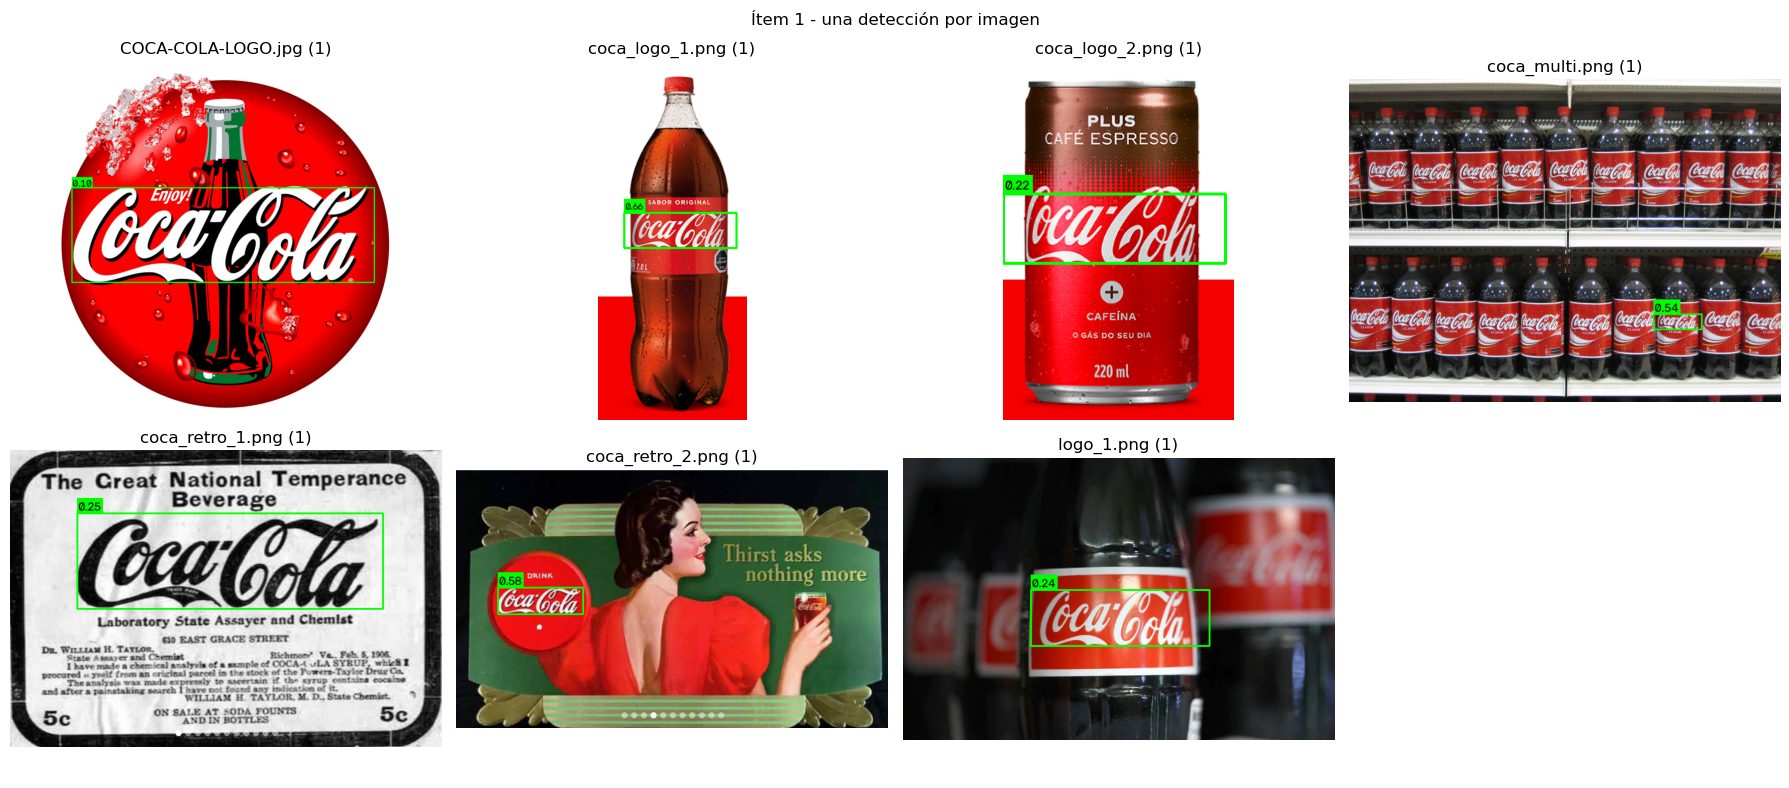

In [20]:
resultados_1 = {}
for nombre, img in imagenes.items():
    gris = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    mejor, _, _ = mejor_deteccion(gris)
    resultados_1[nombre] = [mejor]
    print(f"{nombre:20s} conf={mejor['conf']:.2f}")

mostrar_todas(resultados_1, 'Ítem 1 - una detección por imagen')

## Punto 2: Múltiples detecciones en `coca_multi.png`

1. Con la búsqueda del ítem 1 se obtiene la escala del mejor logo. Se buscan candidatos en esa escala y en las 2 vecinas de cada lado (en una misma foto los logos tienen tamaños parecidos).
2. Umbral relativo: se aceptan los puntos cuyo `z` llega al 70% del `z` de la mejor detección.
3. Supresión de no máximos: candidatos ordenados de mayor a menor `z`, se descarta todo el que tenga IoU > 0.3 con uno ya elegido.

In [21]:
def iou(a, b):
    x1, y1 = max(a['x'], b['x']), max(a['y'], b['y'])
    x2 = min(a['x'] + a['w'], b['x'] + b['w'])
    y2 = min(a['y'] + a['h'], b['y'] + b['h'])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    union = a['w'] * a['h'] + b['w'] * b['h'] - inter
    return inter / union


def nms(candidatos, umbral_iou=0.3):
    candidatos = sorted(candidatos, key=lambda d: d['z'], reverse=True)
    elegidos = []
    for c in candidatos:
        if all(iou(c, e) <= umbral_iou for e in elegidos):
            elegidos.append(c)
    return elegidos


def detecciones_multiples(gris, rel=0.7, vecinas=2):
    mejor, escalas, picos_z = mejor_deteccion(gris)
    i = int(np.argmax(picos_z))
    edges_img = bordes(gris)

    candidatos = []
    for s in escalas[max(0, i - vecinas): i + vecinas + 1]:
        t = template_escalado(s)
        res = cv.matchTemplate(edges_img, bordes(t), cv.TM_CCOEFF_NORMED)
        z = (res - res.mean()) / res.std()

        ys, xs = np.where(z >= rel * mejor['z'])
        for y, x in zip(ys, xs):
            candidatos.append({'x': int(x), 'y': int(y), 'w': t.shape[1], 'h': t.shape[0],
                               'conf': float(res[y, x]), 'z': float(z[y, x])})

    return nms(candidatos)

Detecciones: 14


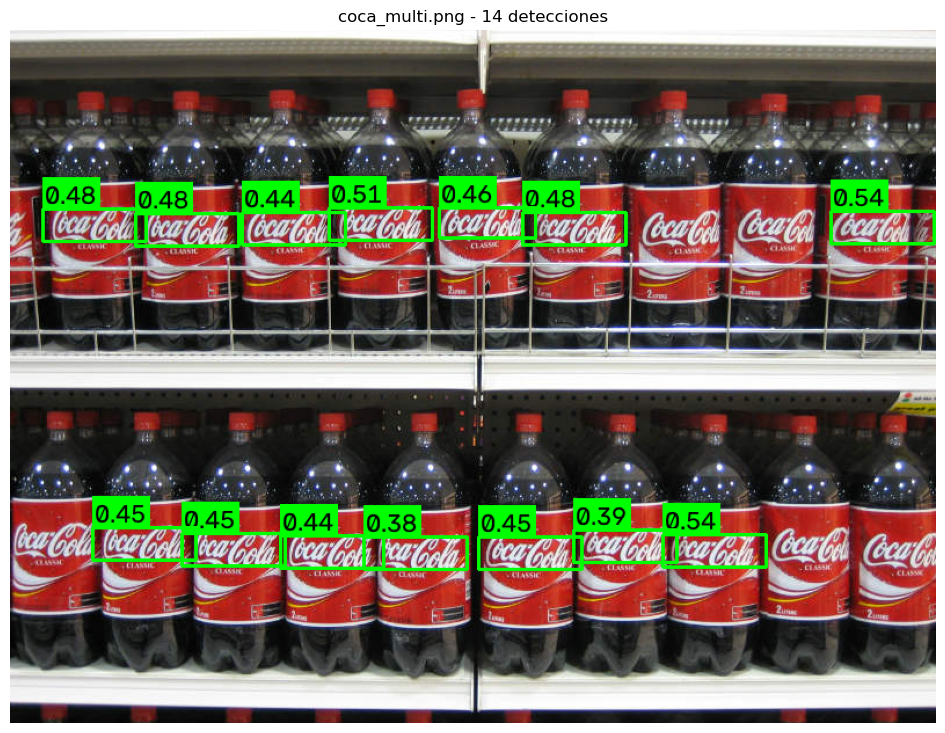

In [22]:
img_multi = imagenes['coca_multi.png']
dets_multi = detecciones_multiples(cv.cvtColor(img_multi, cv.COLOR_BGR2GRAY))
print('Detecciones:', len(dets_multi))

plt.figure(figsize=(12, 9))
plt.imshow(dibujar(img_multi, dets_multi))
plt.title(f'coca_multi.png - {len(dets_multi)} detecciones')
plt.axis('off')
plt.show()

**Validación:** las 14 detecciones caen sobre logos y no hay ninguna en estantes, tapas o precios. Quedan sin detectar los logos cortados en los bordes de la foto y algunos con reflejos. Bajar el umbral recupera algunos de esos logos pero también agrega falsos positivos (ver `TP3_EXPLORACION.ipynb`), por eso se dejó en 70%.

## Punto 3: Generalización a todas las imágenes

Aplicado tal cual, el algoritmo del ítem 2 genera falsos positivos en las imágenes que tienen un solo logo. Como el umbral es relativo a la mejor detección, cualquier estructura con bordes parecidos que llegue al 70% pasa como detección.

Por eso se agrega una verificación con información que los bordes no usan: la correlación en **escala de grises** entre el template y la región detectada, en valor absoluto, porque en varias imágenes el logo está invertido (blanco sobre rojo). Una detección extra se acepta si queda al menos 3 desvíos estándar por encima de la media de ese mapa. La mejor detección (la del ítem 1) se mantiene siempre.

In [23]:
def z_gris(gris, d, cache):
    clave = (d['w'], d['h'])
    if clave not in cache:
        t = cv.resize(template, (d['w'], d['h']), interpolation=cv.INTER_AREA)
        res = np.abs(cv.matchTemplate(gris, t, cv.TM_CCOEFF_NORMED))
        cache[clave] = (res - res.mean()) / res.std()
    return cache[clave][d['y'], d['x']]


def detectar_logos(img_bgr, min_sigma=3):
    gris = cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY)
    dets = detecciones_multiples(gris)

    cache = {}
    finales = [dets[0]]
    for d in dets[1:]:
        if z_gris(gris, d, cache) >= min_sigma:
            finales.append(d)
    return finales

COCA-COLA-LOGO.jpg    1 detecciones  [0.10]
coca_logo_1.png       1 detecciones  [0.66]
coca_logo_2.png       1 detecciones  [0.22]
coca_multi.png       14 detecciones  [0.54, 0.54, 0.51, 0.48, 0.48, 0.48, 0.45, 0.45, 0.45, 0.44, 0.44, 0.46, 0.39, 0.38]
coca_retro_1.png      1 detecciones  [0.25]
coca_retro_2.png      1 detecciones  [0.58]
logo_1.png            1 detecciones  [0.24]


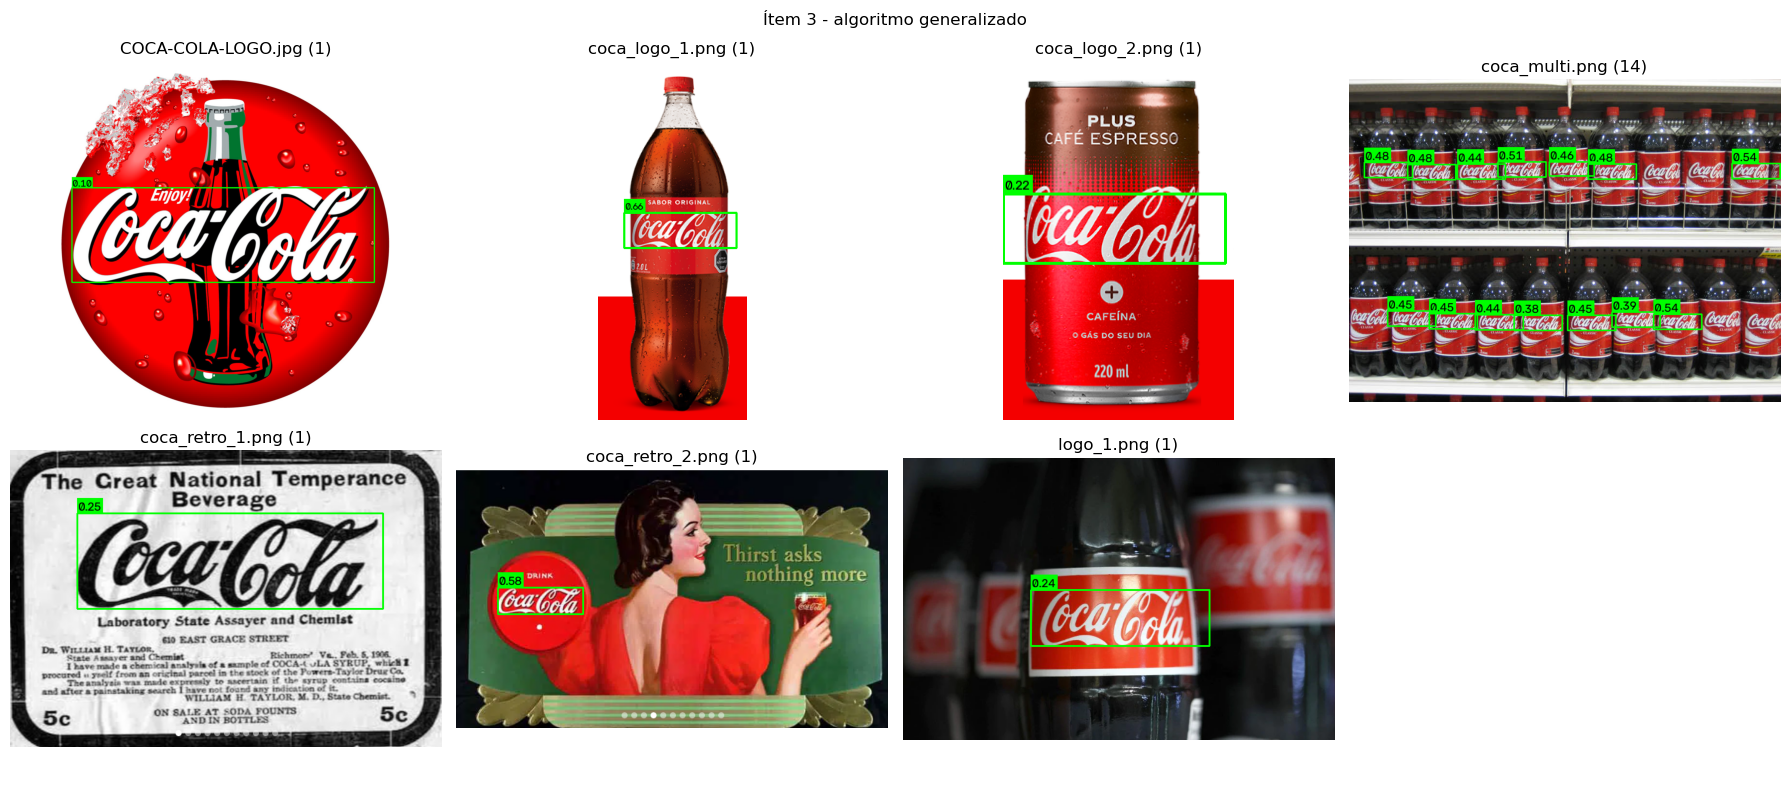

In [24]:
resultados_3 = {}
for nombre, img in imagenes.items():
    resultados_3[nombre] = detectar_logos(img)
    confs = ', '.join(f"{d['conf']:.2f}" for d in resultados_3[nombre])
    print(f'{nombre:20s} {len(resultados_3[nombre]):2d} detecciones  [{confs}]')

mostrar_todas(resultados_3, 'Ítem 3 - algoritmo generalizado')

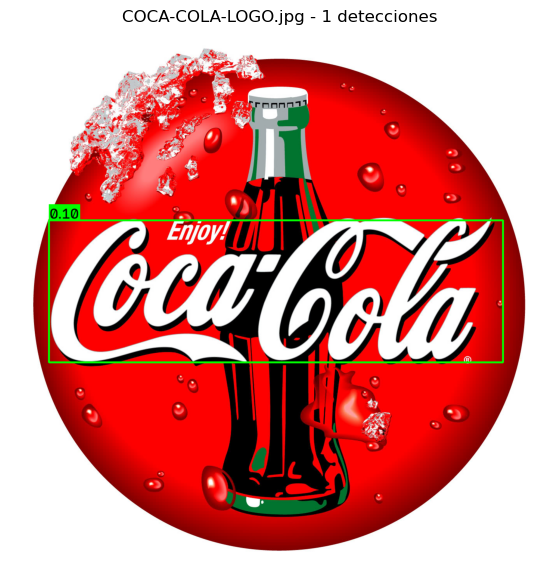

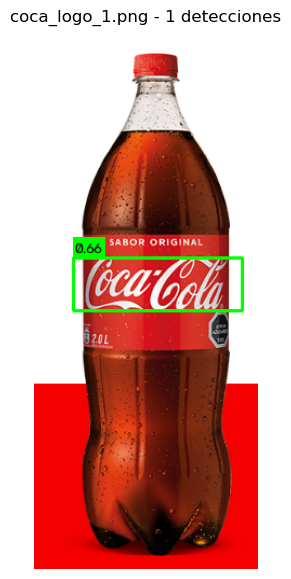

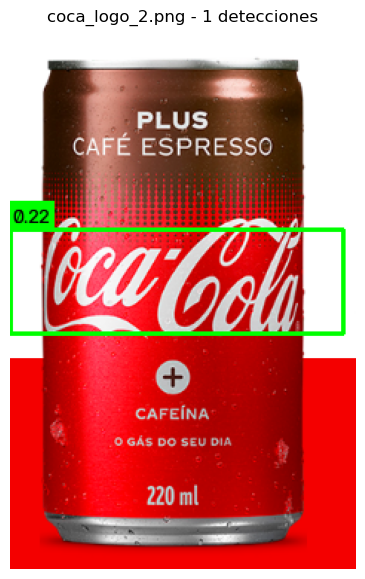

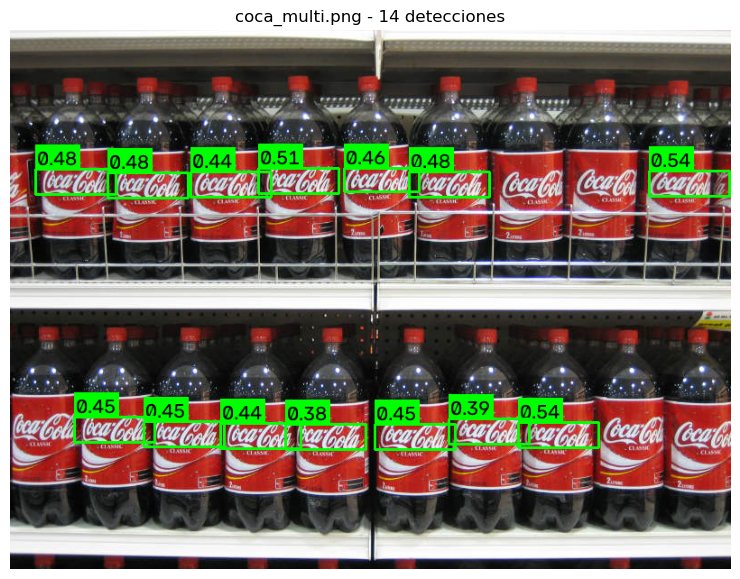

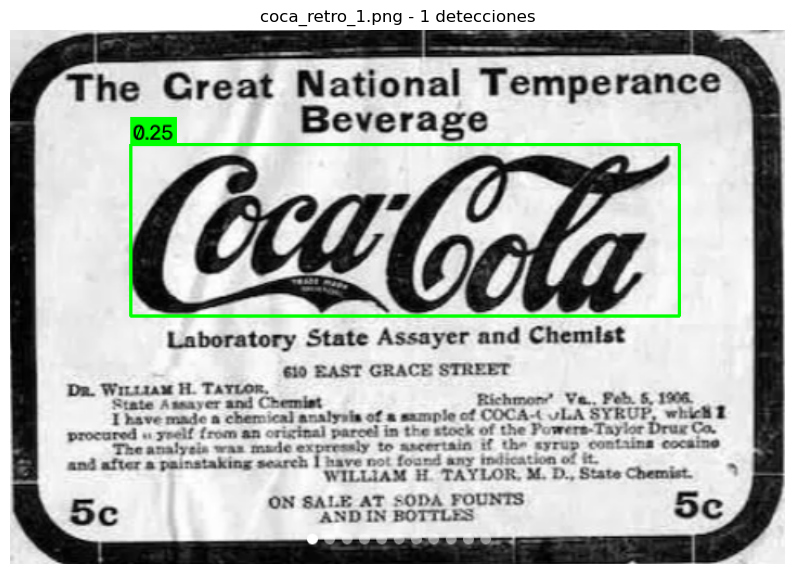

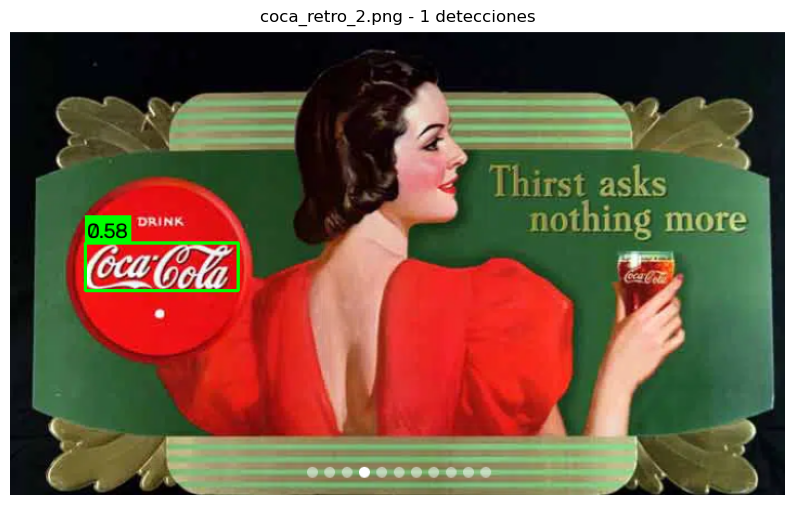

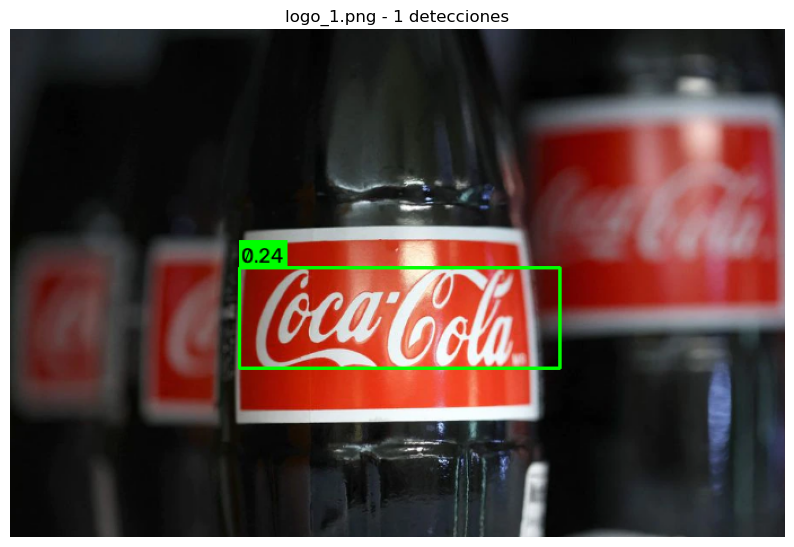

In [25]:
for nombre, dets in resultados_3.items():
    plt.figure(figsize=(10, 7))
    plt.imshow(dibujar(imagenes[nombre], dets))
    plt.title(f'{nombre} - {len(dets)} detecciones')
    plt.axis('off')
    plt.show()

## Conclusiones

- Trabajar sobre bordes permitió usar un único template para logos rojo sobre blanco, blanco sobre rojo y negro sobre blanco.
- Elegir la escala por `z` en lugar del máximo de `TM_CCOEFF_NORMED` resolvió el ítem 1 en las 7 imágenes sin falsos positivos.
- Umbral relativo + NMS con IoU: 14 logos en `coca_multi.png`.
- Al generalizar, la verificación en escala de grises elimina los falsos positivos de las imágenes con un solo logo sin perder ninguno de `coca_multi.png`.
- Limitaciones: no contempla rotaciones ni deformaciones fuertes (el logo curvado de la lata en `coca_logo_2.png` se detecta con un puntaje bajo), y los valores de confianza no son probabilidades ni son comparables entre imágenes.